<a href="https://colab.research.google.com/github/sjsu-cs122-s26/Fast-And-Curious-Traffic-Accidents-Analysis/blob/main/notebooks/CS122_Team_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount dataset CSV file
from google.colab import drive

mount_path = '/content/drive'

drive.mount(mount_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports ↓


In [ ]:
import pandas as pd
import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

In [ ]:
# DO NOT LOAD ENTIRE DATASET

file_path = "/content/drive/Shareddrives/CS122-Team-9/US_Accidents_March23.csv"

columns_needed = [
    "ID",
    "Severity",
    "City"
]

# Load entire dataset
# df = pandas.read_csv(file_path, usecols=columns_needed)


In [ ]:
# Preview first ten columns
df_preview = pandas.read_csv(file_path, usecols=columns_needed, nrows=20)

df_preview

,ID,Severity,City
0,A-1,3,Dayton
1,A-2,2,Reynoldsburg
2,A-3,2,Williamsburg
3,A-4,3,Dayton
4,A-5,2,Dayton
5,A-6,3,Westerville
6,A-7,2,Dayton
7,A-8,3,Dayton
8,A-9,2,Dayton
9,A-10,3,Westerville


In [ ]:
columns_needed = [
    "ID",
    "Severity",           # Accident severity scale (1~4)
    "Start_Time",         # Date and time accident started
    "End_Time",           # Date and time accident ended
    "Start_Lat",          # Latitude (for map visualization)
    "Start_Lng",          # Longitude (for map visualization)
    "City",               # City where accident occurred
    "State",              # State where accident occurred
    "Weather_Condition",  # Weather at time of accident (Rain, Snow, Clear, etc.)
    "Temperature(F)",     # Temperature in Fahrenheit
    "Humidity(%)",        # Humidity percentage
    "Visibility(mi)",     # Visibility in miles
    "Wind_Speed(mph)",    # Wind speed in mph
    "Precipitation(in)",  # Precipitation amount in inches
    "Sunrise_Sunset",     # Day or Night
    "Junction",           # Whether accident occurred at a junction
    "Traffic_Signal",     # Whether a traffic signal was present
]

df = pandas.read_csv(file_path, usecols=columns_needed)

In [ ]:
df.head()

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,City,State,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition,Junction,Traffic_Signal,Sunrise_Sunset
0,A-1,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,Dayton,OH,36.9,91.0,10.0,NaN,0.02,Light Rain,False,False,Night
1,A-2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,Reynoldsburg,OH,37.9,100.0,10.0,NaN,0.00,Light Rain,False,False,Night
2,A-3,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,Williamsburg,OH,36.0,100.0,10.0,3.5,NaN,Overcast,False,True,Night
3,A-4,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,Dayton,OH,35.1,96.0,9.0,4.6,NaN,Mostly Cloudy,False,False,Night
4,A-5,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,Dayton,OH,36.0,89.0,6.0,3.5,NaN,Mostly Cloudy,False,True,Day


In [ ]:
# Print shape, column names, and null counts
print("=== Shape ===")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

=== Shape ===
Rows: 7,728,394  |  Columns: 17


In [ ]:
print("\n=== Null Counts ===")
print(df.isnull().sum())


=== Null Counts ===
ID                         0
Severity                   0
Start_Time                 0
End_Time                   0
Start_Lat                  0
Start_Lng                  0
City                     253
State                      0
Temperature(F)        163853
Humidity(%)           174144
Visibility(mi)        177098
Wind_Speed(mph)       571233
Precipitation(in)    2203586
Weather_Condition     173459
Junction                   0
Traffic_Signal             0
Sunrise_Sunset         23246
dtype: int64


In [ ]:
print("\n=== Data Types ===")
print(df.dtypes)


=== Data Types ===
ID                    object
Severity               int64
Start_Time            object
End_Time              object
Start_Lat            float64
Start_Lng            float64
City                  object
State                 object
Temperature(F)       float64
Humidity(%)          float64
Visibility(mi)       float64
Wind_Speed(mph)      float64
Precipitation(in)    float64
Weather_Condition     object
Junction                bool
Traffic_Signal          bool
Sunrise_Sunset        object
dtype: object


In [ ]:
# Convert Start_Time and End_Time to datetime format
df["Start_Time"] = pandas.to_datetime(df["Start_Time"], format='mixed')
df["End_Time"]   = pandas.to_datetime(df["End_Time"], format='mixed')

In [ ]:
# Extract time-based features for analysis
df["Hour"]      = df["Start_Time"].dt.hour
df["DayOfWeek"] = df["Start_Time"].dt.day_name()
df["Month"]     = df["Start_Time"].dt.month
df["Year"]      = df["Start_Time"].dt.year

In [ ]:
# Convert boolean columns to integers (True/False → 1/0)
bool_cols = ["Junction", "Traffic_Signal"]
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
# Drop rows where critical columns are null
critical = ["Severity", "Start_Time", "Start_Lat", "Start_Lng", "State"]
df_clean = df.dropna(subset=critical)

In [ ]:
# Fill null values in non-critical columns
df_clean["Weather_Condition"] = df_clean["Weather_Condition"].fillna("Unknown")
df_clean["Sunrise_Sunset"]    = df_clean["Sunrise_Sunset"].fillna("Unknown")
df_clean["Precipitation(in)"] = df_clean["Precipitation(in)"].fillna(0.0)

In [ ]:
print(f"Before cleaning: {df.shape[0]:,} rows")
print(f"After cleaning:  {df_clean.shape[0]:,} rows")
print(f"Dropped: {df.shape[0] - df_clean.shape[0]:,} rows")

Before cleaning: 7,728,394 rows
After cleaning:  7,728,394 rows
Dropped: 0 rows


#For Apr 14th?

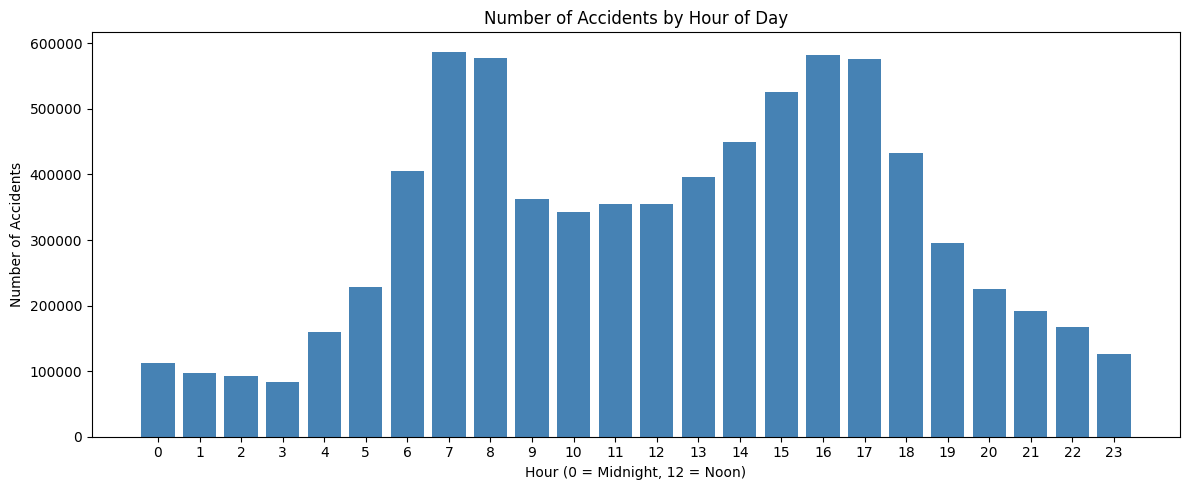

In [ ]:
# Accidents by hour of day
hourly = df_clean["Hour"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(hourly.index, hourly.values, color="steelblue")
plt.title("Number of Accidents by Hour of Day")
plt.xlabel("Hour (0 = Midnight, 12 = Noon)")
plt.ylabel("Number of Accidents")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

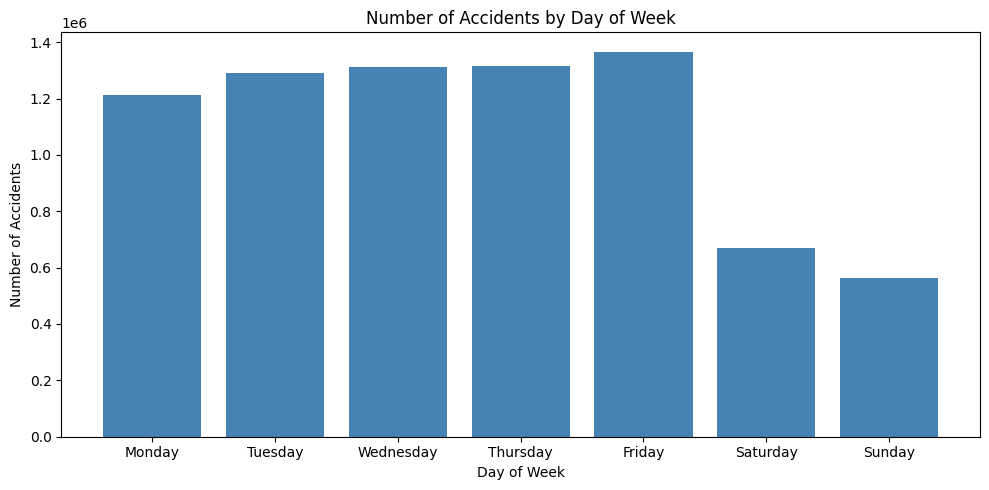

In [ ]:
# Accidents by day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily = df_clean["DayOfWeek"].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
plt.bar(daily.index, daily.values, color="steelblue")
plt.title("Number of Accidents by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

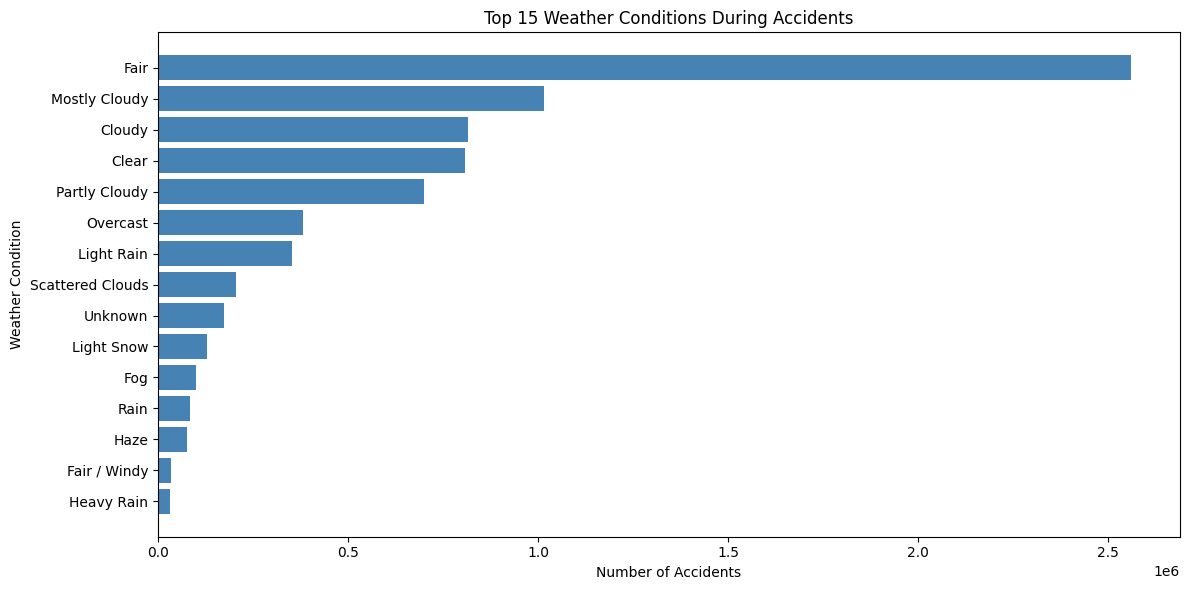

In [ ]:
# Top 15 weather conditions by accident count
weather = df_clean["Weather_Condition"].value_counts().head(15)

plt.figure(figsize=(12, 6))
plt.barh(weather.index[::-1], weather.values[::-1], color="steelblue")
plt.title("Top 15 Weather Conditions During Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Weather Condition")
plt.tight_layout()
plt.show()

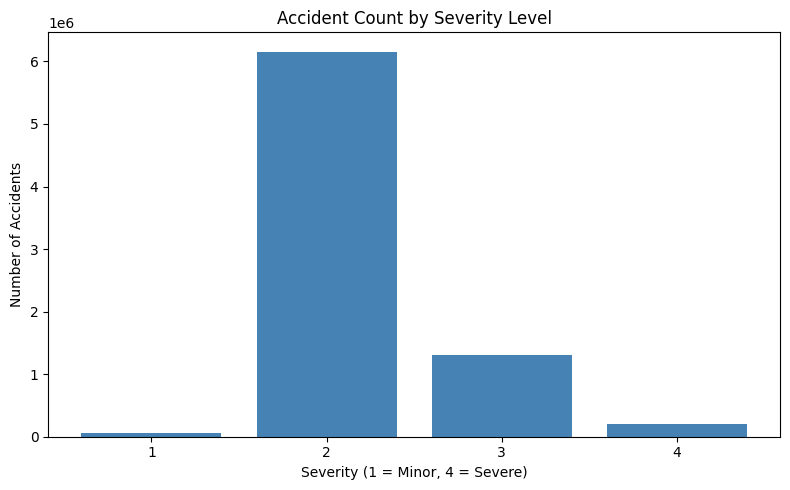

In [ ]:
# Accident count by severity level (1=minor, 4=severe)
severity = df_clean["Severity"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(severity.index, severity.values, color="steelblue")
plt.title("Accident Count by Severity Level")
plt.xlabel("Severity (1 = Minor, 4 = Severe)")
plt.ylabel("Number of Accidents")
plt.xticks([1, 2, 3, 4])
plt.tight_layout()
plt.show()

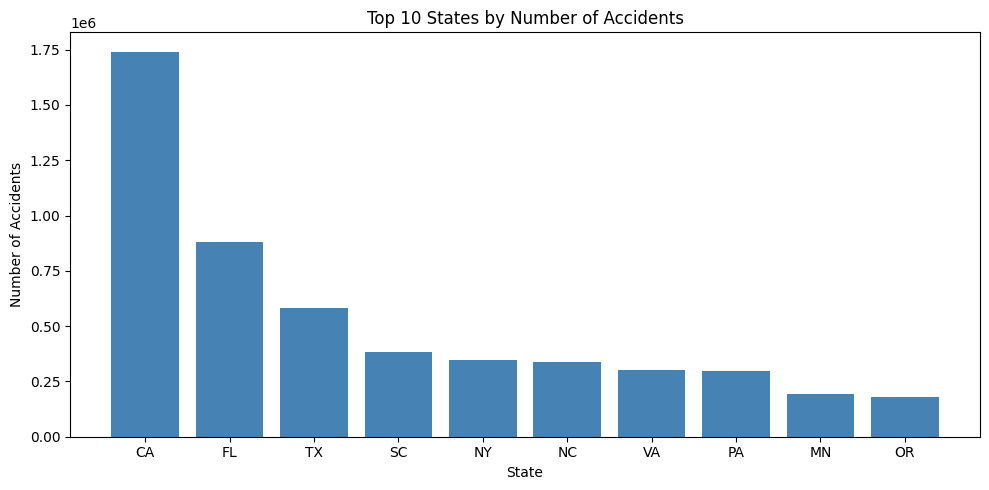

In [ ]:
# Top 10 states by accident count
top_states = df_clean["State"].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_states.index, top_states.values, color="steelblue")
plt.title("Top 10 States by Number of Accidents")
plt.xlabel("State")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

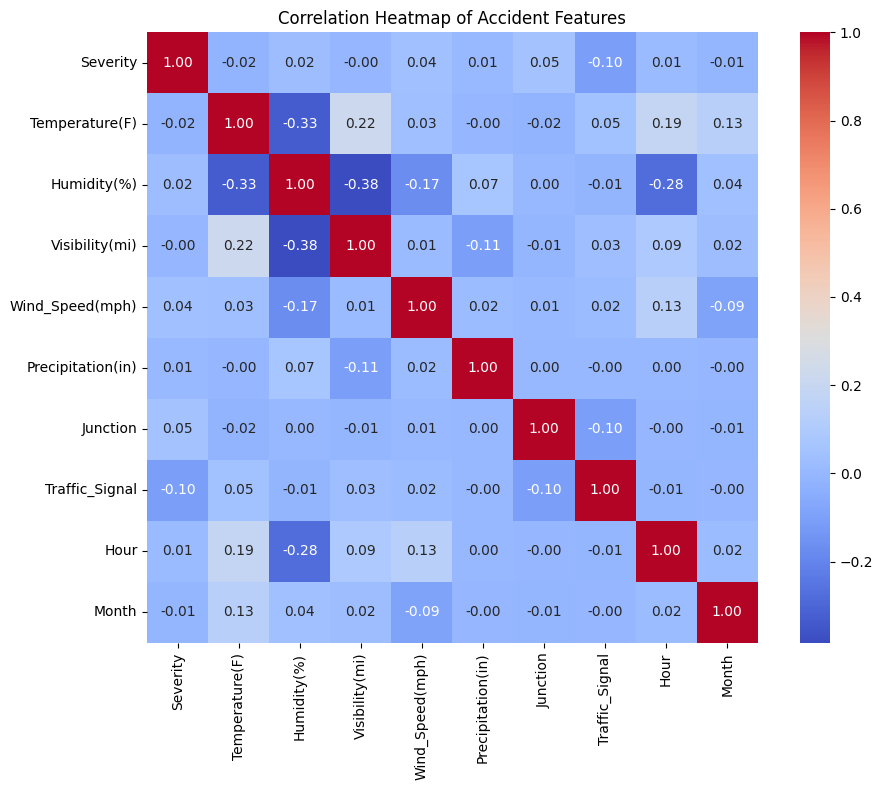

In [ ]:
# Correlation heatmap of numerical columns
num_cols = ["Severity", "Temperature(F)", "Humidity(%)",
            "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)",
            "Junction", "Traffic_Signal", "Hour", "Month"]

corr = df_clean[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Accident Features")
plt.tight_layout()
plt.show()

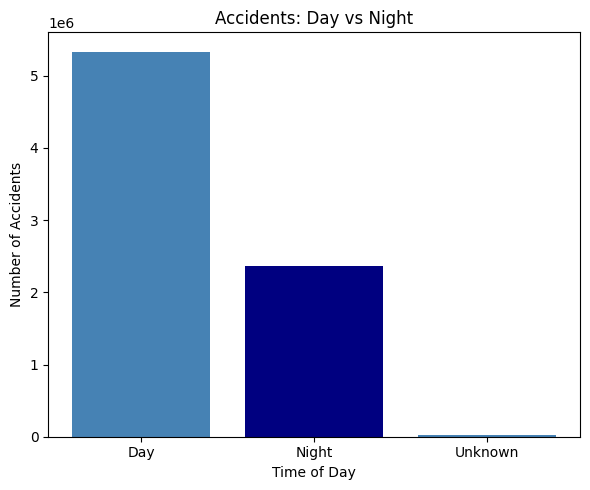

In [ ]:
# Accidents by day vs night
day_night = df_clean["Sunrise_Sunset"].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(day_night.index, day_night.values, color=["steelblue", "navy"])
plt.title("Accidents: Day vs Night")
plt.xlabel("Time of Day")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

In [ ]:
df_sample = df_clean[["Start_Lat", "Start_Lng"]].dropna().sample(50000, random_state=42)

m = folium.Map(location=[37.0902, -95.7129], zoom_start=4)
HeatMap(df_sample.values.tolist(), radius=3, blur=4).add_to(m)

In [ ]:
m

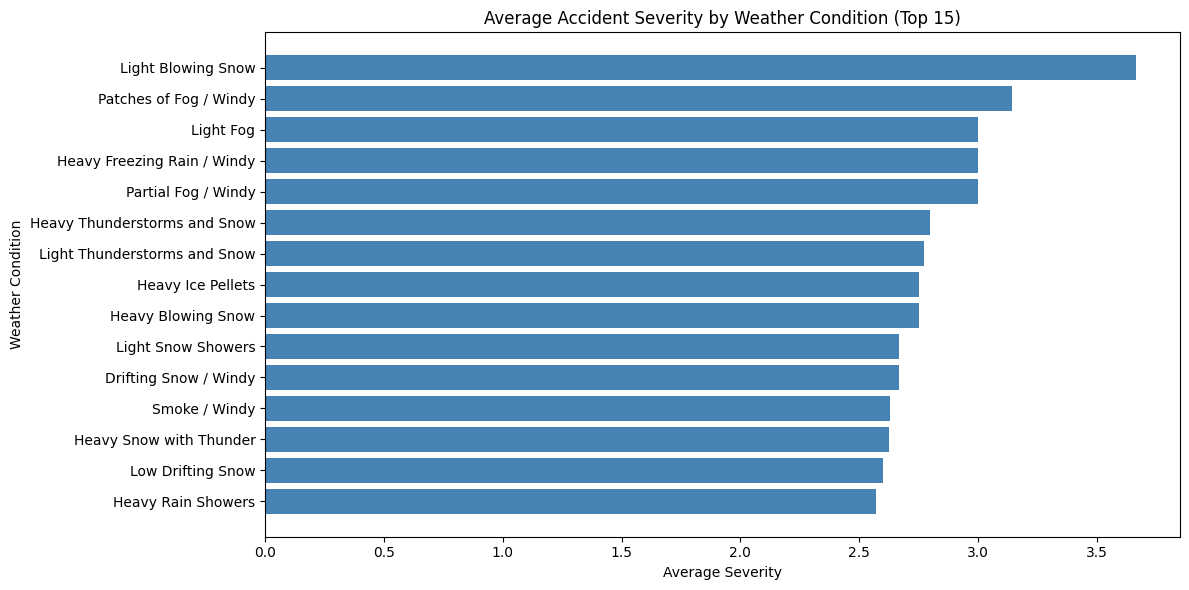

In [ ]:
# Average severity by weather condition (Top 15)
weather_severity = df_clean.groupby("Weather_Condition")["Severity"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.barh(weather_severity.index[::-1], weather_severity.values[::-1], color="steelblue")
plt.title("Average Accident Severity by Weather Condition (Top 15)")
plt.xlabel("Average Severity")
plt.ylabel("Weather Condition")
plt.tight_layout()
plt.show()